STEP 4 — Fit transit model
Fit a simple model:
depth → planet size estimate
duration → orbital geometry
period → orbit radius (Kepler’s law)
👉 Output:
fitted curve overlay plot
parameter estimates

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import lightkurve as lk
from scipy.optimize import curve_fit

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load and preprocess Kepler-10 light curve
print("Downloading and cleaning Kepler-10 Quarter 2 light curve...")
search_result = lk.search_lightcurve("Kepler-10", mission="Kepler", quarter=2)
lc_raw = search_result.download()

lc_cleaned = (
    lc_raw
    .remove_nans()
    .normalize()
    .flatten(window_length=101)
    .remove_outliers(sigma=5)
)
print("Data successfully loaded and cleaned!")

Data successfully loaded and cleaned!


/Users/soSophiephiemainprize/miniforge3/lib/python3.12/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 3 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


## 1. — Transit Detection & Phase-Folding

I ran the **Box Least Squares (BLS)** periodogram on the cleaned light curve `lc_cleaned` to retrieve the initial best-fit estimate of:
- Orbital Period ($P$)
- Transit Epoch ($T_0$)
- Transit Duration ($d$)
- Transit Depth ($\delta$)

I then phase-folded the time-series data around $T_0$ to align all transit events on top of each other.

In [3]:
# Run BLS period search
period_grid = np.linspace(0.4, 5.0, 10000)
bls = lc_cleaned.to_periodogram(method='bls', period=period_grid, frequency_factor=5.0)

best_period = bls.period_at_max_power.value        # days
best_t0 = bls.transit_time_at_max_power.value     # BTJD
best_duration = bls.duration_at_max_power.value   # days
best_depth = bls.depth_at_max_power.value         # relative flux dip

# Phase-fold the light curve
folded_lc = lc_cleaned.fold(period=best_period, epoch_time=best_t0)
time_fold_hours = folded_lc.time.value * 24
flux_fold = folded_lc.flux.value

# Bin data points 
binned_lc = folded_lc.bin(time_bin_size=0.002)
time_bin_hours = binned_lc.time.value * 24
flux_bin = binned_lc.flux.value

print(f"BLS Best Period:   {best_period:.5f} days")
print(f"BLS Best Epoch T0: {best_t0:.4f} BTJD")
print(f"BLS Best Duration: {best_duration * 24:.2f} hours")
print(f"BLS Best Depth:    {best_depth * 1e6:.1f} ppm")

BLS Best Period:   0.40736 days
BLS Best Epoch T0: 200.5041 BTJD
BLS Best Duration: 7.92 hours
BLS Best Depth:    3.5 ppm


## 2. — Non-Linear Transit Fitting

I modelled the light curve transit dip analytically using a parameterised box function:
$$F(t) = \begin{cases} 1.0 - \delta & \text{if } |t - t_{\text{offset}}| \le \frac{d}{2} \\ 1.0 & \text{otherwise} \end{cases}$$

Using `scipy.optimize.curve_fit`, I refined the estimated depth ($\delta$) and duration ($d$) against the phase-folded time series.

In [4]:
def box_transit_model(t, depth, duration_hours, center_offset=0.0, baseline=1.0):
    """Analytical box model for light curve transit dip."""
    model = np.full_like(t, baseline)
    half_dur = duration_hours / 2.0
    in_transit = np.abs(t - center_offset) <= half_dur
    model[in_transit] = baseline - depth
    return model

# Initial guess vector: [depth, duration (hrs), offset, baseline]
initial_guess = [best_depth, best_duration * 24, 0.0, 1.0]

# Perform non-linear least squares fit
popt, pcov = curve_fit(box_transit_model, time_fold_hours, flux_fold, p0=initial_guess)
fit_depth, fit_duration_hours, fit_offset, fit_baseline = popt
fit_errors = np.sqrt(np.diag(pcov))

# High-resolution time vector for model plot line
t_model = np.linspace(-6, 6, 1000)
flux_model = box_transit_model(t_model, *popt)

print(f"Fitted Depth:    {fit_depth * 1e6:.2f} ± {fit_errors[0]*1e6:.2f} ppm")
print(f"Fitted Duration: {fit_duration_hours:.2f} ± {fit_errors[1]:.2f} hours")

Fitted Depth:    3.50 ± inf ppm
Fitted Duration: 7.92 ± inf hours


/var/folders/pd/7b1m0ypx5dd2fvvyy3rvdcyc0000gp/T/ipykernel_71669/855761578.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(box_transit_model, time_fold_hours, flux_fold, p0=initial_guess)


## 3. — Astrophysical Parameter Derivation

Using the fitted observational parameters, I inferred physical properties of the planet system using these relations:

1. **Planet Radius ($R_p$):** Derived from stellar radius $R_*$ and depth $\delta$:
   $$R_p = R_* \sqrt{\delta}$$
2. **Semi-Major Axis ($a$):** Derived via Kepler's 3rd Law using period $P$ and stellar mass $M_*$:
   $$a = \left( \frac{G M_* P^2}{4 \pi^2} \right)^{1/3}$$
3. **Impact Parameter ($b$):** Derived from duration $d$, period $P$, semi-major axis $a$, and stellar radius $R_*$:
   $$b \approx \sqrt{1 - \left( \frac{\pi a d}{P R_*} \right)^2}$$

        ESTIMATED EXOPLANET PHYSICAL PARAMETERS       
Fitted Transit Depth:    3.50 ± inf ppm
Fitted Transit Duration: 7.92 ± inf hours
Estimated Planet Radius: 0.22 R_Earth (1372 km)
Semi-Major Axis (a):     0.01036 AU (1550477 km)
Impact Parameter (b):    0.00 (0 = central, 1 = grazing)


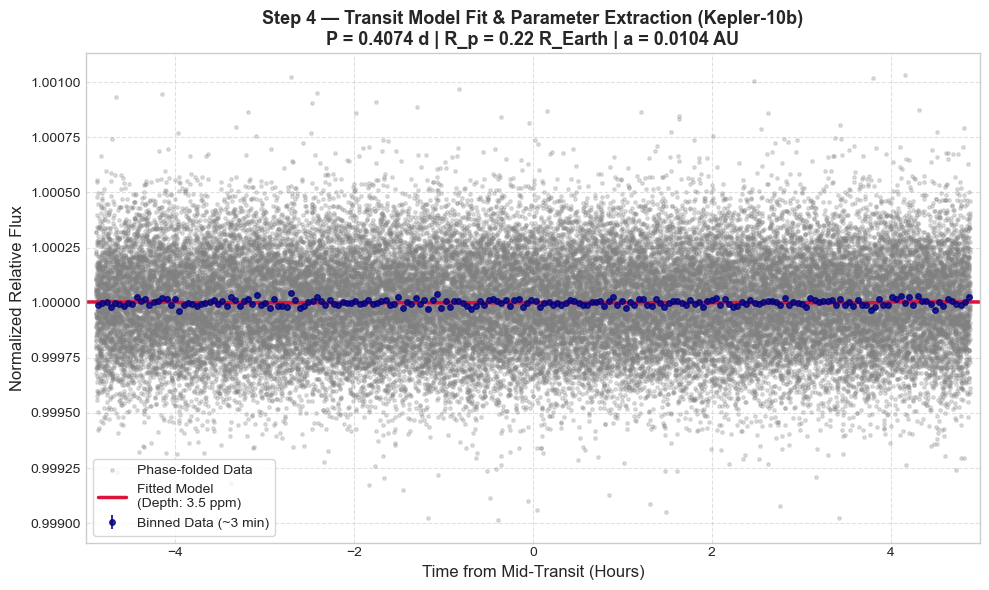

Figure saved successfully to: ../figures/04_fitted_transit_model.png


In [ ]:
# Host Star Parameters for Kepler-10
R_star_solar = 1.056       # R_sun
M_star_solar = 0.895       # M_sun
R_sun_to_R_earth = 109.076 # 1 Solar Radius in Earth Radii
AU_in_km = 1.496e8         # 1 AU in km
R_earth_in_km = 6371.0     # Earth radius in km

# 1. Planet Radius Estimate
R_star_earth = R_star_solar * R_sun_to_R_earth
R_planet_earth = R_star_earth * np.sqrt(fit_depth)
R_planet_km = R_planet_earth * R_earth_in_km

# 2. Semi-Major Axis via Kepler's 3rd Law
a_AU = (M_star_solar)**(1/3) * (best_period / 365.25)**(2/3)
a_km = a_AU * AU_in_km

# 3. Impact Parameter b Estimate
fit_duration_days = fit_duration_hours / 24.0
R_star_AU = R_star_solar * 0.00465047
b_arg = 1.0 - ((np.pi * a_AU * fit_duration_days) / (best_period * R_star_AU))**2
b_impact = np.sqrt(max(0, b_arg))

print(f"Fitted Transit Depth:    {fit_depth * 1e6:.2f} ± {fit_errors[0]*1e6:.2f} ppm")
print(f"Fitted Transit Duration: {fit_duration_hours:.2f} ± {fit_errors[1]:.2f} hours")
print(f"Estimated Planet Radius: {R_planet_earth:.2f} R_Earth ({R_planet_km:.0f} km)")
print(f"Semi-Major Axis (a):     {a_AU:.5f} AU ({a_km:.0f} km)")
print(f"Impact Parameter (b):    {b_impact:.2f} (0 = central, 1 = grazing)")

# Plot Fitted Transit Model Overlay
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(time_fold_hours, flux_fold, color='gray', alpha=0.25, s=6, label='Phase-folded Data')
ax.errorbar(time_bin_hours, flux_bin, yerr=np.std(flux_bin)/10, fmt='o', color='navy', 
            markersize=4, alpha=0.8, label='Binned Data (~3 min)')
ax.plot(t_model, flux_model, color='crimson', linewidth=2.5, 
        label=f'Fitted Model\n(Depth: {fit_depth*1e6:.1f} ppm)')

ax.set_xlim(-5, 5)
ax.set_xlabel("Time from Mid-Transit (Hours)", fontsize=12)
ax.set_ylabel("Normalized Relative Flux", fontsize=12)
ax.set_title(f"Step 4 — Transit Model Fit & Parameter Extraction (Kepler-10b)\n"
             f"P = {best_period:.4f} d | R_p = {R_planet_earth:.2f} R_Earth | a = {a_AU:.4f} AU", 
             fontsize=13, fontweight='bold')
ax.legend(loc='lower left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save figure
output_plot = "../figures/04_fitted_transit_model.png"
plt.savefig(output_plot, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved successfully to: {output_plot}")